# Age-75 to age-105 counterfactual mesh rollout

This is an **out-of-distribution stress test**, not a validated forecast of anatomy at age 105. The selected source meshes come from validation subjects near age 75. Each source is transported under both CN and AD conditions using (1) one direct age-75-to-target call and (2) annual recursive composition.

The notebook is load-only: it reads meshes, tables, and HTML created by `run_ood_rollout.py`. It performs no model inference and never loads the test split.


## Load the completed stress test

Run the script first. The following cell stops with a clear command if its output is absent.


In [9]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, IFrame, Markdown, display

TASK_DIR = Path('/home/jakaria/INR/Deep3DComp/examples/ADNI_1_LHipp_LLV_No_MCI_synthseg_minimal_smooth/task6_ood_mesh_rollout_v1')
RESULT_DIR = Path('/mnt/bulk10tb/Deep3DComp/ADNI_1_LHipp/task6_ood_mesh_rollout_v1/age75_to105_v1')
REPORT_DIR = TASK_DIR / 'reports' / 'age75_to105_v1'
summary_path = RESULT_DIR / 'summary.json'
if not summary_path.is_file():
    raise FileNotFoundError('Run scripts/run_ood_rollout.py first; see RUNBOOK.md')
summary = json.loads(summary_path.read_text())
metrics = pd.read_csv(RESULT_DIR / 'tables' / 'trajectory_metrics.csv', dtype={'source_scan_id': str, 'source_subject_id': str})
divergence = pd.read_csv(RESULT_DIR / 'tables' / 'composition_disagreement.csv', dtype={'source_scan_id': str})
contrast = pd.read_csv(RESULT_DIR / 'tables' / 'condition_contrast.csv')
assert summary['status'] == 'complete' and summary['split'] == 'val'
assert summary['test_data_loaded'] is False
print('Loaded', summary['generated_meshes'], 'saved meshes')
print('Training age support:', summary['direct_training_age_range_years'])
print('Requested final age:', summary['final_age_years'])


Loaded 112 saved meshes
Training age support: [55.099998474121094, 95.62053680419922]
Requested final age: 105


## What is being compared

- **One-shot:** the original age-75 state is sent directly to each target age.
- **Annual composition:** the output at one year becomes the input for the next year. Mesh-space errors or latent-space drift can therefore accumulate.
- **Condition switch:** the same source state is evaluated under CN and AD labels. This is a model counterfactual, not an observed conversion from CN to AD.

Agreement between one-shot and composed paths is evidence of extrapolated cocycle consistency. It is not evidence that either path is biologically correct.


In [10]:
display(pd.DataFrame(summary['sources']).rename(columns={
    'diagnosis': 'Source group', 'scan_id': 'Scan', 'subject_id': 'Subject',
    'actual_age_years': 'Actual scan age', 'model_source_age_years': 'Model start age',
    'volume_mm3': 'Source volume (mm3)'
}).round(3))
display(pd.DataFrame(summary['methods']).T)


,Actual scan age,Source group,Model start age,Scan,selection_score,Subject,Source volume (mm3)
0,75.281,CN,75.0,1250_m24,0.157,1250,3822.440
1,75.231,AD,75.0,83_m24,0.299,83,2495.749


,checkpoint_epoch,label
latent_spiral,1,Latent Spiral
mesh_adaptive,56,Mesh Adaptive


## Volume trajectory and composition disagreement

The left panels show predicted volume divided by source volume. The opaque lines are one-shot predictions and faint lines are annual composition. The right panels show mean vertex distance between those two paths. Large separation means the learned cocycle does not remain stable under repeated OOD composition.


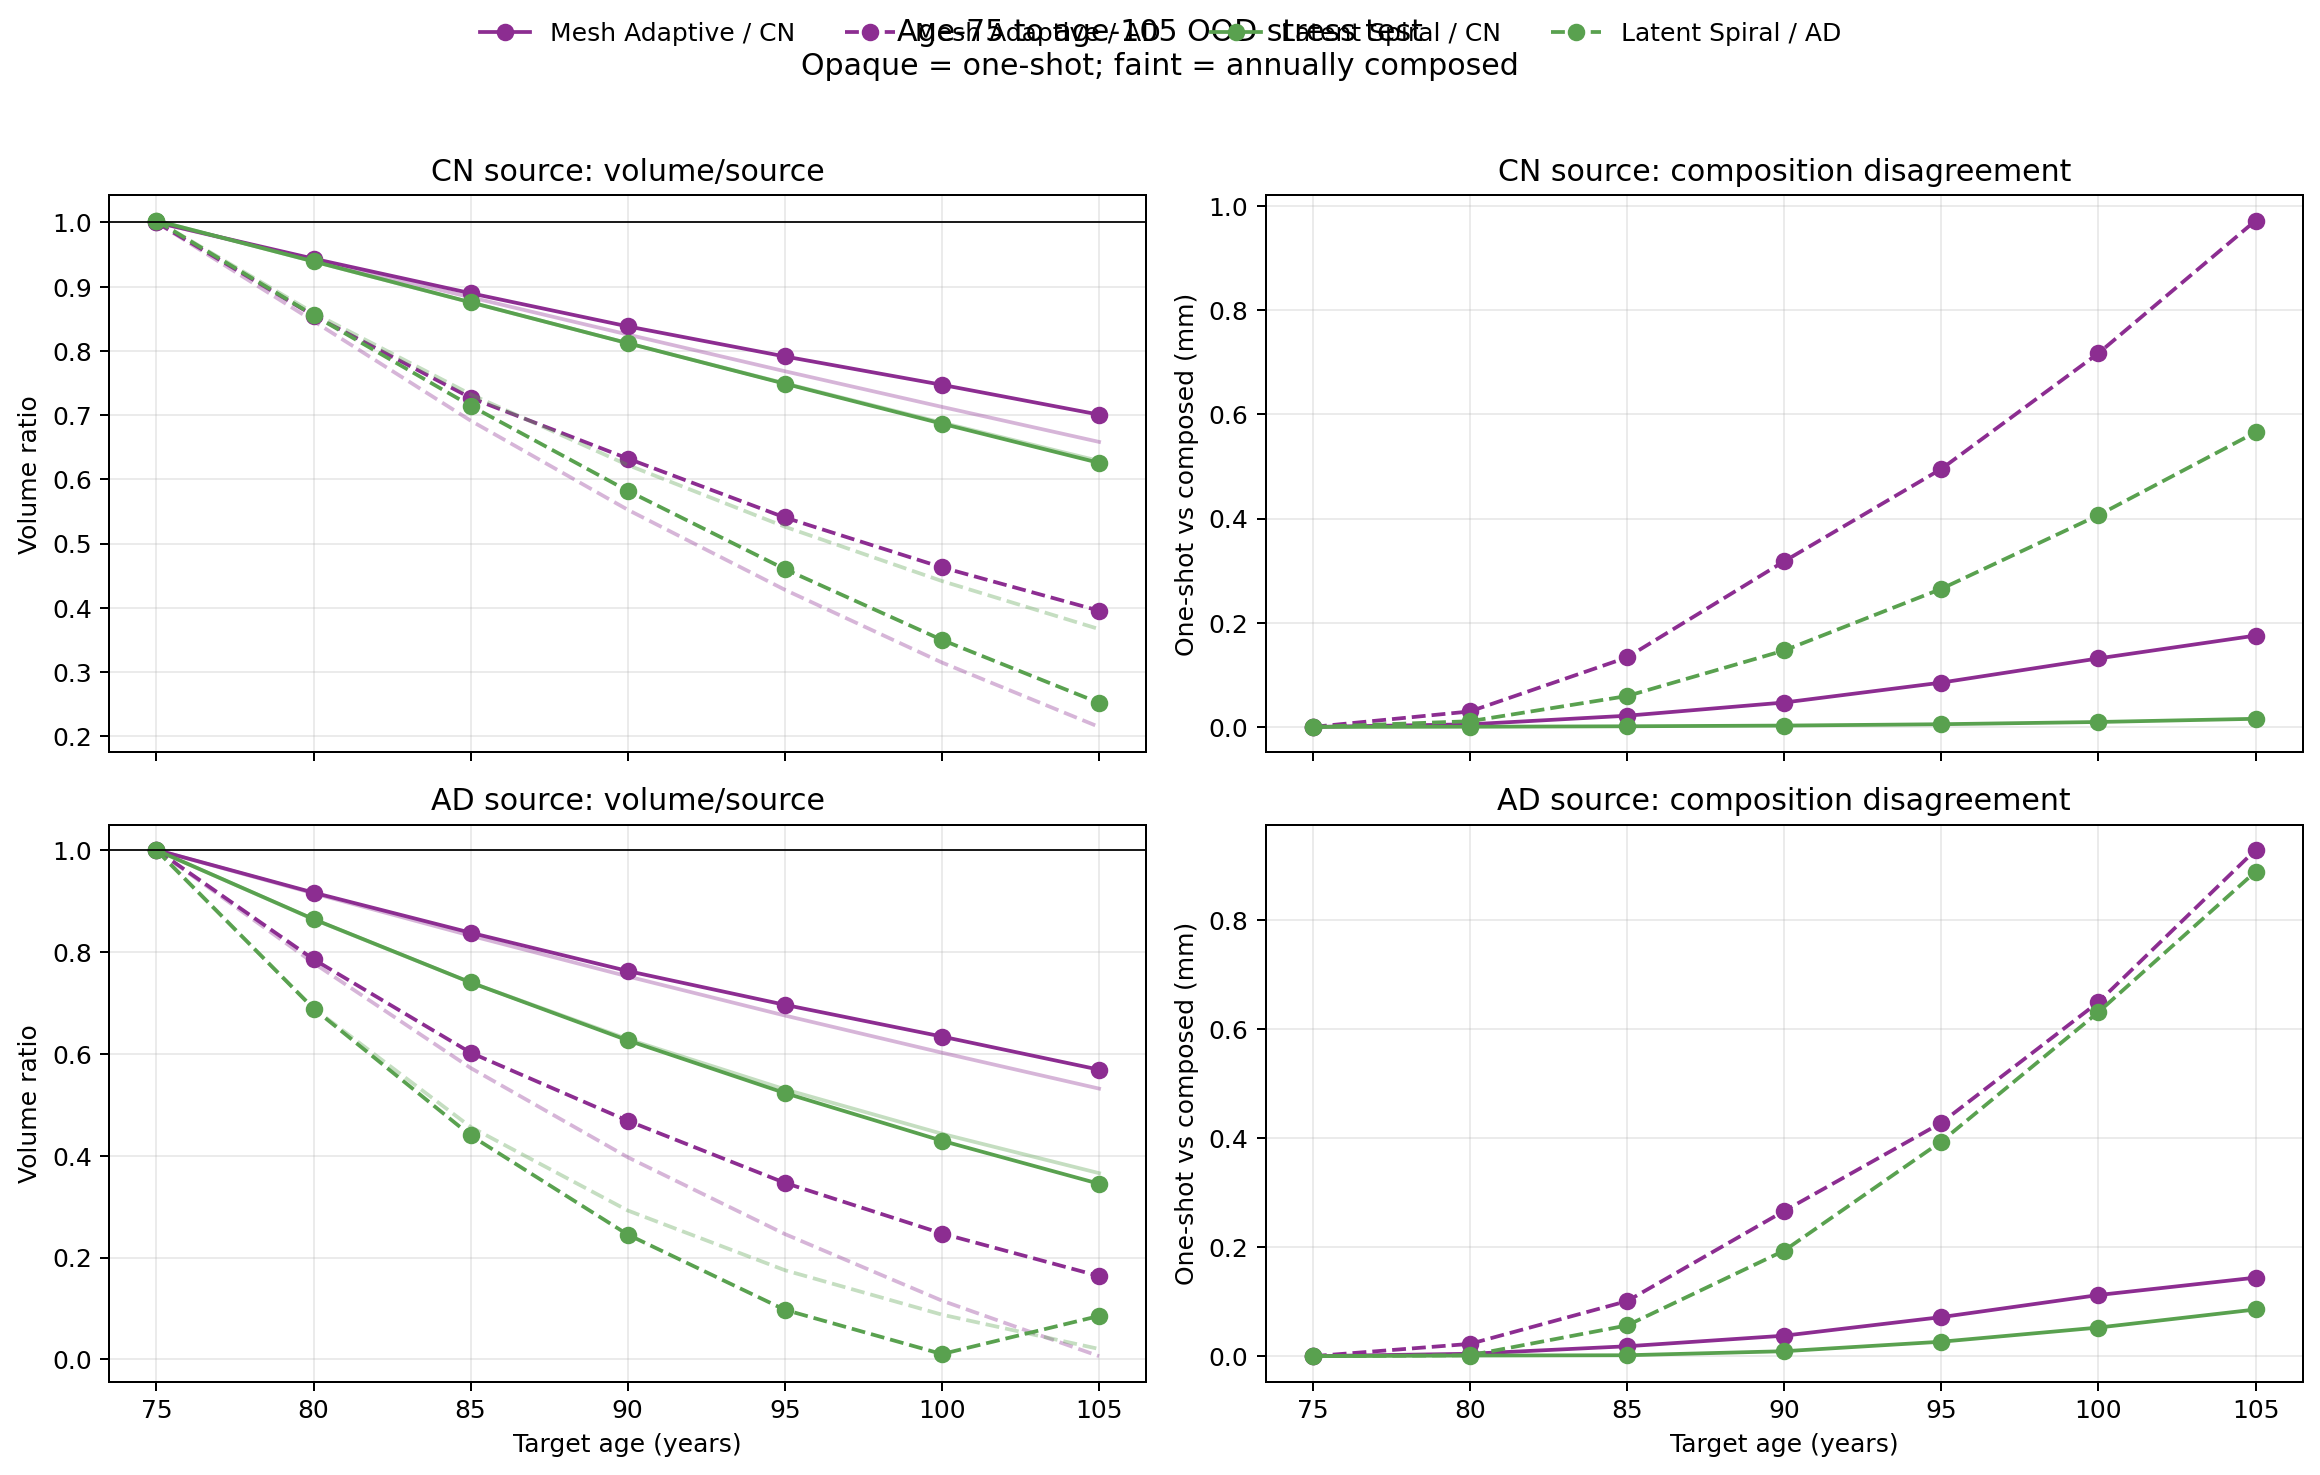

In [11]:
display(Image(filename=str(REPORT_DIR / 'ood_volume_and_composition.png')))


## Age-105 geometric diagnostics

`Structural pass` checks finite vertices, face orientation, degeneracy, broad volume limits, edge distortion, and maximum displacement. Passing these checks only means the file remains a numerically usable mesh. Self-intersection and biological plausibility are not certified. `Nearest training mesh RMSE` measures how far the prediction moves from the observed training-shape set.


In [12]:
final = metrics[metrics.age_years.eq(summary['final_age_years'])].copy()
columns = [
    'method_label', 'source_diagnosis', 'condition', 'rollout', 'mesh_generated',
    'structural_guardrail_pass', 'volume_ratio', 'mean_vertex_displacement_mm',
    'maximum_vertex_displacement_mm', 'flipped_face_fraction',
    'edge_ratio_p01', 'edge_ratio_p99', 'nearest_training_mesh_rmse_mm'
]
display(final[columns].rename(columns={
    'method_label': 'Method', 'source_diagnosis': 'Source', 'condition': 'Condition',
    'rollout': 'Rollout', 'mesh_generated': 'Mesh generated',
    'structural_guardrail_pass': 'Structural pass', 'volume_ratio': 'Volume/source',
    'mean_vertex_displacement_mm': 'Mean displacement (mm)',
    'maximum_vertex_displacement_mm': 'Maximum displacement (mm)',
    'flipped_face_fraction': 'Flipped-face fraction',
    'edge_ratio_p01': 'Edge ratio p01', 'edge_ratio_p99': 'Edge ratio p99',
    'nearest_training_mesh_rmse_mm': 'Nearest training mesh RMSE (mm)'
}).round(4))


,Method,Source,Condition,Rollout,Mesh generated,Structural pass,Volume/source,Mean displacement (mm),Maximum displacement (mm),Flipped-face fraction,Edge ratio p01,Edge ratio p99,Nearest training mesh RMSE (mm)
6,Mesh Adaptive,CN,CN,one_shot,True,False,0.7007,0.9757,1.9655,0.0004,0.7005,1.0880,0.4026
13,Mesh Adaptive,CN,CN,composed,True,False,0.6582,1.0882,2.4609,0.0004,0.6832,1.0920,0.3950
20,Mesh Adaptive,CN,AD,one_shot,True,False,0.3954,2.1417,4.8885,0.0095,0.4332,1.2189,0.7557
27,Mesh Adaptive,CN,AD,composed,True,False,0.2145,2.8481,7.2200,0.0246,0.3679,1.3129,0.9710
34,Mesh Adaptive,AD,CN,one_shot,True,False,0.5687,1.1453,3.1056,0.0004,0.6260,1.1387,0.6855
41,Mesh Adaptive,AD,CN,composed,True,False,0.5316,1.2428,3.3773,0.0004,0.6060,1.1426,0.7101
48,Mesh Adaptive,AD,AD,one_shot,True,False,0.1637,2.5750,7.4011,0.0341,0.3202,1.4243,1.3775
55,Mesh Adaptive,AD,AD,composed,True,False,0.0065,3.2059,8.8539,0.0864,0.2778,1.5078,1.7170
62,Latent Spiral,CN,CN,one_shot,True,True,0.6256,1.2944,2.4449,0.0000,0.6692,1.1081,0.3655
69,Latent Spiral,CN,CN,composed,True,True,0.6286,1.2817,2.4251,0.0000,0.6722,1.1066,0.3629


## Interactive meshes

Each HTML contains two synchronized surfaces: one-shot on the left and annually composed on the right. Use the target-age slider. Colour is displacement from the source mesh. Only the selected direct-mesh and selected explicit latent-mesh methods are included.

Change `SOURCE` and `CONDITION` to any of `CN` or `AD`, then rerun the cells.


In [13]:
def show_rollout(method, source, condition, height=680):
    method = method.lower()
    source = source.lower()
    condition = condition.lower()
    filename = f'{method}__source_{source}__condition_{condition}.html'
    path = REPORT_DIR / filename
    if not path.is_file():
        raise FileNotFoundError(path)
    relative = f'../reports/age75_to105_v1/{filename}'
    display(Markdown(f'### {method}: {source.upper()} source under {condition.upper()} condition'))
    return IFrame(src=relative, width='100%', height=height)

SOURCE = 'AD'
CONDITION = 'AD'
display(show_rollout('mesh_adaptive', SOURCE, CONDITION))


### mesh_adaptive: AD source under AD condition

In [14]:
SOURCE = 'AD'
CONDITION = 'AD'
display(show_rollout('latent_spiral', SOURCE, CONDITION))


### latent_spiral: AD source under AD condition

## Condition and path summaries

A negative `AD minus CN volume ratio` means that the AD condition produces the smaller mesh from exactly the same source. The second table quantifies how far annual composition moves away from one-shot prediction.


In [15]:
display(contrast[contrast.age_years.eq(summary['final_age_years'])].round(4))
display(divergence[divergence.age_years.eq(summary['final_age_years'])].round(4))


,method,method_label,source_diagnosis,rollout,age_years,ad_minus_cn_volume_ratio,ad_condition_smaller_volume
6,mesh_adaptive,Mesh Adaptive,CN,one_shot,105,-0.3053,True
13,mesh_adaptive,Mesh Adaptive,CN,composed,105,-0.4438,True
20,mesh_adaptive,Mesh Adaptive,AD,one_shot,105,-0.4050,True
27,mesh_adaptive,Mesh Adaptive,AD,composed,105,-0.5251,True
34,latent_spiral,Latent Spiral,CN,one_shot,105,-0.3737,True
41,latent_spiral,Latent Spiral,CN,composed,105,-0.2618,True
48,latent_spiral,Latent Spiral,AD,one_shot,105,-0.2593,True
55,latent_spiral,Latent Spiral,AD,composed,105,-0.3450,True


,method,method_label,source_diagnosis,source_scan_id,condition,age_years,mean_vertex_distance_mm,p95_vertex_distance_mm,maximum_vertex_distance_mm,absolute_volume_ratio_difference
6,mesh_adaptive,Mesh Adaptive,CN,1250_m24,CN,105,0.1754,0.4592,0.6350,0.0425
13,mesh_adaptive,Mesh Adaptive,CN,1250_m24,AD,105,0.9721,2.5155,2.9777,0.1809
20,mesh_adaptive,Mesh Adaptive,AD,83_m24,CN,105,0.1441,0.3172,0.4339,0.0372
27,mesh_adaptive,Mesh Adaptive,AD,83_m24,AD,105,0.9286,1.7868,2.3061,0.1573
34,latent_spiral,Latent Spiral,CN,1250_m24,CN,105,0.0156,0.0295,0.0400,0.0030
41,latent_spiral,Latent Spiral,CN,1250_m24,AD,105,0.5658,0.8864,1.1394,0.1148
48,latent_spiral,Latent Spiral,AD,83_m24,CN,105,0.0857,0.1353,0.1676,0.0209
55,latent_spiral,Latent Spiral,AD,83_m24,AD,105,0.8888,1.4156,1.8609,0.0648


## Interpretation limits

The training data end near age 96, so ages 100 and 105 are unsupported extrapolation. A decoder producing a closed-looking surface does not establish that the latent state remains on the anatomical manifold. Likewise, a direct-mesh model preserving topology can still create folded or biologically implausible geometry. Treat the results as a failure-mode audit and condition-sensitivity demonstration, not as a 30-year clinical forecast.
